# Import Library and Loading DataSet

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# load dataset
import pandas as pd
df = pd.read_excel("/Users/joao/Desktop/Data Visualisation & Communication/Data-Visualisation/all_data_M_2023.xlsx",engine="openpyxl")


## get the location of the files

In [ ]:
import os
os.getcwd()

## visualisation the structure of the dataset rows/columns

In [ ]:
df.head()

In [ ]:
df.shape

In [ ]:
df.info()

In [ ]:
df.columns

# now lets filter the information
## we know dataset has 413327 rows and 32 columns
following we need to select only the data we need to perform our data visualisation

# Display a list of 50 first  Occupation Tittle of the dataset

In [ ]:
df["OCC_TITLE"].head(50)

# We must select only relevants fields

## OCC_TITTLE:Occupation Tittle
## TOT_EMP: Total of Employees
## A_MEAN: Annual Mean Wage
## AREA_TITTLE

In [ ]:
# List of keywords related to AI, Data Science and Software Development

keywords = [
    "Artificial",
    "Intelligence",
    "AI",
    "Machine Learning",
    "Deep Learning",
    "Data Scientist",
    "Data Analyst",
    "Data Engineer",
    "Data Architect",
    "Database",
    "Big Data",
    "Statistician",
    "Operations Research",
    "Software",
    "Developer",
    "Engineer",
    "Programmer",
    "Application",
    "Systems",
    "Web",
    "Full Stack",
    "Cloud"
]
# shows all content of the field
pd.set_option("display.max_colwidth", None)

# pattern to find job occupations
pattern = r"\b(" + "|".join(keywords) + r")\b"

# filter related to keywords
df_ai = df[df["OCC_TITLE"].str.contains(pattern, case=False, na=False)]

# display 20 first results
df_ai[["OCC_TITLE", "TOT_EMP", "A_MEAN", "AREA_TITLE"]]

# Applying Manual filter for irrelevant Occupations

In [ ]:
exclude = ["Fire Alarm", "Aircraft", "Installers", "Assemblers"]

df_ai = df[
    df["OCC_TITLE"].str.contains(pattern, case=False, na=False) &
    ~df["OCC_TITLE"].str.contains('|'.join(exclude), case=False, na=False)
]


In [ ]:
df_ai_unique = df_ai.drop_duplicates(subset=["OCC_TITLE"])
df_ai_unique[["OCC_TITLE", "TOT_EMP", "A_MEAN", "AREA_TITLE"]]

# Follow step  we must convert strings values in numerical values
## TOT_EMP to Integer

In [ ]:
# 1) Make sure  TOT_EMP is numerical values

import pandas as pd

df_ai["TOT_EMP"] = (
    df_ai["TOT_EMP"]
      .astype(str)                                #  string
      .str.replace(r"[^\d\.-]", "", regex=True)   # remove NO numerical digits.)
      .replace({"": pd.NA})                       # empt strings  -> NA
      .pipe(pd.to_numeric, errors="coerce")       # convert to numerical values;
)

# 2) Ordenate and pick  top 10 lines 
top10 = (
    df_ai.groupby("OCC_TITLE", as_index=False)["TOT_EMP"]
          .sum(min_count=1)   
          .sort_values("TOT_EMP", ascending=False)
          .head(10)
)

# HORIZONTAL BAR PLOT

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,6))
sns.barplot(x="TOT_EMP", y="OCC_TITLE", data=top10, palette="viridis")
plt.title("Top 10 Occupations in AI, Data Science and Software", fontsize=16, color="blue")
plt.xlabel(" EMPLOYEES (in millions)", fontsize=16, color="blue")
plt.ylabel("Occupation", fontsize=16, color="green")
plt.show()



In [ ]:
# Aggregate employment by occupation
emp_by_occ = (
    df_ai.groupby("OCC_TITLE", as_index=False)["TOT_EMP"]
    .sum(min_count=1)
    .sort_values("TOT_EMP", ascending=False))

# Select top 10 occupations
top10 = emp_by_occ.head(10).copy()
others_sum = emp_by_occ["TOT_EMP"].iloc[10:].sum()
top10 = pd.concat([top10, pd.DataFrame({"OCC_TITLE": ["Others"], "TOT_EMP": [others_sum]})], ignore_index=True)

# Define colors
colors = sns.color_palette("Set2", len(top10))

# Explode the biggest slice
explode = [0.1 if i == top10["TOT_EMP"].idxmax() else 0 for i in range(len(top10))]

# Aggregate employment by occupation
emp_by_occ = (
    df_ai.groupby("OCC_TITLE", as_index=False)["TOT_EMP"]
         .sum(min_count=1)
         .sort_values("TOT_EMP", ascending=False)
)

In [ ]:
# Define colors
colors = sns.color_palette("Set2", len(top10))

# Explode the biggest slice
explode = [0.1 if i == top10["TOT_EMP"].idxmax() else 0 for i in range(len(top10))]

# Plot
plt.figure(figsize=(12,15))
wedges, texts, autotexts = plt.pie(
    top10["TOT_EMP"],
    labels=None,  # remove labels from inside pie
    autopct="%1.1f%%",
    startangle=0,
    colors=colors,
    explode=explode,
    textprops={'fontsize':12, 'weight':'bold'}
)

# Add legend outside the pie
plt.legend(
    wedges,
    top10["OCC_TITLE"],
    title="Occupations",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)

plt.title("Percentage of Employees by Occupation (Top 10 + Others)", fontsize=20, color="blue")
plt.tight_layout()
plt.show()

In [ ]:
df_scatter = df_ai.copy()

# Ensure numeric
df_scatter["A_MEAN"]  = pd.to_numeric(df_scatter["A_MEAN"],  errors="coerce")
df_scatter["TOT_EMP"] = pd.to_numeric(df_scatter["TOT_EMP"], errors="coerce")

# Keep valid rows
df_scatter = df_scatter.dropna(subset=["A_MEAN", "TOT_EMP"])
df_scatter = df_scatter[df_scatter["TOT_EMP"] > 0]

# Weighted mean wage by occupation
df_scatter["_wage_weight"] = df_scatter["A_MEAN"] * df_scatter["TOT_EMP"]
agg = (
    df_scatter.groupby("OCC_TITLE", as_index=False)
              .agg(TOT_EMP=("TOT_EMP", "sum"),
                   WAGE_WEIGHT=("_wage_weight", "sum"))
)
agg["A_MEAN_WEIGHTED"] = agg["WAGE_WEIGHT"] / agg["TOT_EMP"]



In [ ]:
# Pick a manageable subset (top by employment)
scatter_df = agg.sort_values("TOT_EMP", ascending=False).head(10).copy()
plt.figure(figsize=(14,8))
sns.scatterplot(
    data=scatter_df,
    x="TOT_EMP",
    y="A_MEAN_WEIGHTED",
    s=(scatter_df["TOT_EMP"] / scatter_df["TOT_EMP"].max()) * 800 + 50
)
plt.title("Employment vs. Weighted Mean Wage by Occupation (Top 10)",fontsize=25,)
plt.xlabel("Total Employment",fontsize=15,)
plt.ylabel("Weighted Mean Annual Wage (USD)", fontsize= 15)

for _, row in scatter_df.head(10).iterrows():
    plt.annotate(row["OCC_TITLE"], (row["TOT_EMP"], row["A_MEAN_WEIGHTED"]),
                 xytext=(5,5), textcoords="offset points", fontsize=5)

plt.tight_layout()
plt.show()

In [ ]:
# --- Clean copy and numeric conversion ---
box_df = df_ai.copy()

# Ensure numeric columns (coerce invalid strings like '-', '*', 'N/A' to NaN)
box_df["A_MEAN"]  = pd.to_numeric(box_df["A_MEAN"],  errors="coerce")
box_df["TOT_EMP"] = pd.to_numeric(box_df["TOT_EMP"], errors="coerce")

# Keep only valid rows
box_df = box_df.dropna(subset=["A_MEAN", "TOT_EMP"])
box_df = box_df[(box_df["A_MEAN"] > 0) & (box_df["TOT_EMP"] > 0)]

# --- Choose top occupations by employment (after cleaning) ---
top_occ = (
    box_df.groupby("OCC_TITLE", as_index=False)["TOT_EMP"].sum()
          .sort_values("TOT_EMP", ascending=False)
          .head(5)["OCC_TITLE"]
          .tolist()
)

box_df = box_df[box_df["OCC_TITLE"].isin(top_occ)].copy()

# --- Order occupations by median wage for nicer ordering ---
order_by_median = (
    box_df.groupby("OCC_TITLE")["A_MEAN"]
          .median()
          .sort_values(ascending=False)
          .index
          .tolist()
)

In [ ]:
# --- Plot (boxplot of wage by occupation) ---
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=box_df,
    x="A_MEAN",
    y="OCC_TITLE",
    order=order_by_median
)
plt.title("Distribution of Annual Mean Wages by Occupation (Top 5 by Employment)")
plt.xlabel("Annual Mean Wage (USD)")
plt.ylabel("Occupation")
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
# --- Clean copy and numeric conversion ---
violin_df = df_ai.copy()

# Ensure numeric
violin_df["A_MEAN"]  = pd.to_numeric(violin_df["A_MEAN"],  errors="coerce")
violin_df["TOT_EMP"] = pd.to_numeric(violin_df["TOT_EMP"], errors="coerce")

# Keep valid rows
violin_df = violin_df.dropna(subset=["A_MEAN", "TOT_EMP"])
violin_df = violin_df[(violin_df["A_MEAN"] > 0) & (violin_df["TOT_EMP"] > 0)]

# --- Choose top occupations by employment (after cleaning) ---
top_occ = (
    violin_df.groupby("OCC_TITLE", as_index=False)["TOT_EMP"].sum()
             .sort_values("TOT_EMP", ascending=False)
             .head(5)["OCC_TITLE"]
             .tolist()
)

violin_df = violin_df[violin_df["OCC_TITLE"].isin(top_occ)].copy()

# Order occupations by median wage for consistent left-to-right ranking
order_by_median = (
    violin_df.groupby("OCC_TITLE")["A_MEAN"]
             .median()
             .sort_values(ascending=False)
             .index
             .tolist()
)

In [ ]:
# --- Violin plot ---
plt.figure(figsize=(12, 6))
sns.violinplot(
    data=violin_df,
    x="A_MEAN",
    y="OCC_TITLE",
    order=order_by_median,
    inner="quartile",    # show median and quartiles inside violins
    cut=0,               # don’t extend beyond data range
    bw_method="scott"    # smoothing; try 0.3/0.5 if very jagged
)
plt.title("Wage Distribution (Violin) by Occupation — Top 5 by Employment")
plt.xlabel("Annual Mean Wage (USD)")
plt.ylabel("Occupation")
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [24]:
import pandas as pd
import glob
import re

path = "/Users/joao/Desktop/Data Visualisation & Communication/Data-Visualisation/"

# Load CSV files 
files = glob.glob(path + "all_data_M_*.csv")
files

['/Users/joao/Desktop/Data Visualisation & Communication/Data-Visualisation/all_data_M_2024.csv',
 '/Users/joao/Desktop/Data Visualisation & Communication/Data-Visualisation/all_data_M_2021.csv',
 '/Users/joao/Desktop/Data Visualisation & Communication/Data-Visualisation/all_data_M_2020.csv',
 '/Users/joao/Desktop/Data Visualisation & Communication/Data-Visualisation/all_data_M_2022.csv',
 '/Users/joao/Desktop/Data Visualisation & Communication/Data-Visualisation/all_data_M_2023.csv']

In [25]:
# List of keywords related to AI, Data Science and Software Development
keywords = [
    "Artificial",
    "Intelligence",
    "AI",
    "Machine Learning",
    "Deep Learning",
    "Data Scientist",
    "Data Analyst",
    "Data Engineer",
    "Data Architect",
    "Database",
    "Big Data",
    "Statistician",
    "Operations Research",
    "Software",
    "Developer",
    "Programmer",
    "Web",
    "Full Stack",
    "Cloud"
]

pattern = r"\b(" + "|".join(keywords) + r")\b"

df_list = []

for file in files:
    # Extract year from filename
    year_match = re.search(r"(\d{4})", file)
    if year_match:
        year = int(year_match.group(1))
    else:
        continue

    # Read CSV fast
    df = pd.read_csv(file, low_memory=False)

    # Convert numeric columns
    df["A_MEAN"]  = pd.to_numeric(df["A_MEAN"], errors="coerce")
    df["TOT_EMP"] = pd.to_numeric(df["TOT_EMP"], errors="coerce")

    # Filter for target occupations
    df_filtered = df[df["OCC_TITLE"].str.contains(pattern, case=False, na=False)].copy()
    df_filtered["YEAR"] = year
    
    df_list.append(df_filtered)

# Combine all years into one DataFrame
df_all_years = pd.concat(df_list, ignore_index=True)

df_all_years.head()


/var/folders/2_/rpqtn9_54tz9phyzqknf_m200000gn/T/ipykernel_36471/2391755312.py:44: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_filtered = df[df["OCC_TITLE"].str.contains(pattern, case=False, na=False)].copy()
/var/folders/2_/rpqtn9_54tz9phyzqknf_m200000gn/T/ipykernel_36471/2391755312.py:44: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_filtered = df[df["OCC_TITLE"].str.contains(pattern, case=False, na=False)].copy()
/var/folders/2_/rpqtn9_54tz9phyzqknf_m200000gn/T/ipykernel_36471/2391755312.py:44: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_filtered = df[df["OCC_TITLE"].str.contains(pattern, case=False, na=False)].copy()
/var/folders/2_/rpqtn9_54tz9phyzqknf_m200000gn/T/ipykernel_36471/2391755312.py:44: UserWarn

,AREA,AREA_TITLE,AREA_TYPE,PRIM_STATE,NAICS,NAICS_TITLE,I_GROUP,OWN_CODE,OCC_CODE,OCC_TITLE,...,H_PCT75,H_PCT90,A_PCT10,A_PCT25,A_MEDIAN,A_PCT75,A_PCT90,ANNUAL,HOURLY,YEAR
0,99,U.S.,1,US,000000,Cross-industry,cross-industry,1235,15-1240,Database and Network Administrators and Archit...,...,66.8,82.79,63580,81390,107480,138940,172190,NaN,NaN,2024
1,99,U.S.,1,US,000000,Cross-industry,cross-industry,1235,15-1242,Database Administrators,...,63.87,77.35,56820,76100,104620,132850,160890,NaN,NaN,2024
2,99,U.S.,1,US,000000,Cross-industry,cross-industry,1235,15-1243,Database Architects,...,81.48,100.96,81630,107900,135980,169480,209990,NaN,NaN,2024
3,99,U.S.,1,US,000000,Cross-industry,cross-industry,1235,15-1250,"Software and Web Developers, Programmers, and ...",...,79.77,99.92,71740,97560,129320,165910,207830,NaN,NaN,2024
4,99,U.S.,1,US,000000,Cross-industry,cross-industry,1235,15-1252,Software Developers,...,81.25,101.66,79850,103050,133080,169000,211450,NaN,NaN,2024


In [27]:
df_all_years["YEAR"].value_counts().sort_index()


YEAR
2020    3612
2021    4767
2022    4880
2023    4963
2024    4955
Name: count, dtype: int64

In [28]:
df_all_years.groupby("YEAR")["OCC_TITLE"].nunique()


YEAR
2020    6
2021    9
2022    9
2023    9
2024    9
Name: OCC_TITLE, dtype: int64

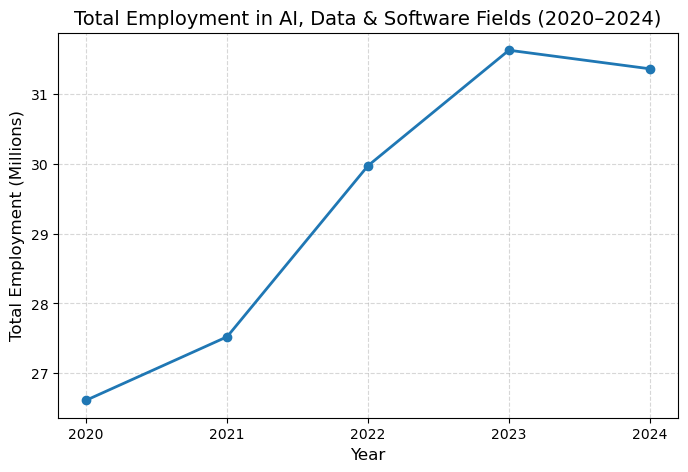

In [30]:
import matplotlib.pyplot as plt

employment_by_year_m = employment_by_year / 1_000_000  # convert to millions

plt.figure(figsize=(8, 5))
plt.plot(employment_by_year_m.index, employment_by_year_m.values, marker="o", linewidth=2)

plt.title("Total Employment in AI, Data & Software Fields (2020–2024)", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Total Employment (Millions)", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.5)
plt.xticks(employment_by_year_m.index)

plt.show()